<a href="https://colab.research.google.com/github/Priya-Kumari-Chourasia/ml_algo/blob/main/adaboost_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.DataFrame()

df['x1'] = [1,2,3,4,5,6,6,7,9,9]
df['x2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [3]:
df

,x1,x2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='x1', ylabel='x2'>

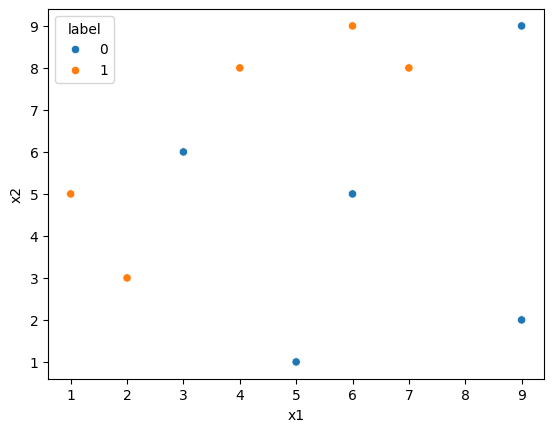

In [4]:
import seaborn as sns
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label'])

In [5]:
df['weights'] = 1/df.shape[0]

In [6]:
df

,x1,x2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [7]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
dt1 = DecisionTreeClassifier(max_depth=1)


In [9]:
x = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [10]:
dt1.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

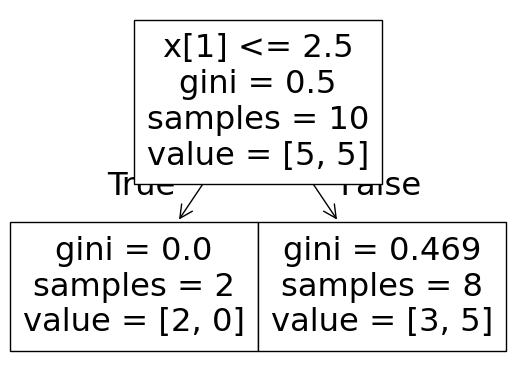

In [11]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

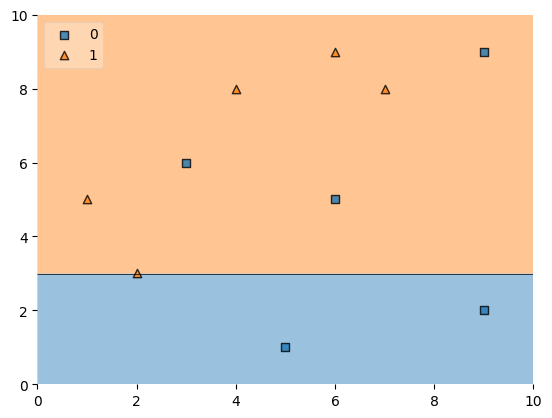

In [12]:
plot_decision_regions(x,y,clf=dt1,legend=2)

In [13]:
df['y_pred'] = dt1.predict(x)

In [14]:
df

,x1,x2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [66]:
def calc_model_wt(error):
  if error == 0:
        return 10.0
  return 0.5*np.log((1-error)/(error))

In [18]:
alpha1 = calc_model_wt(0.3)
alpha1

np.float64(0.42364893019360184)

In [19]:
def update_row_wt(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights']*np.exp(-alpha)
  else:
    return row['weights']*np.exp(alpha)


In [20]:
df['updated_weights'] = df.apply(update_row_wt,axis=1)

In [21]:
df

,x1,x2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [22]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [23]:
df

,x1,x2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [24]:
df['normalized_weights'].sum()

np.float64(1.0)

In [25]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [28]:
df[['x1','x2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,x1,x2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [29]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [30]:
index_values = create_new_dataset(df)

index_values

[1, 6, 1, 3, 4, 5, 0, 2, 7, 7]

In [31]:
second_df = df.iloc[index_values,[0,1,2,3]]


In [32]:
second_df

,x1,x2,label,weights
1,2,3,1,0.1
6,6,5,0,0.1
1,2,3,1,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
0,1,5,1,0.1
2,3,6,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1


In [33]:
dt2 = DecisionTreeClassifier(max_depth=1)


In [34]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values


In [35]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.625, 0.5, '  False')]

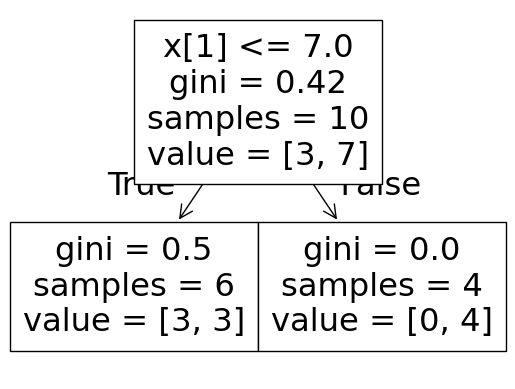

In [36]:
plot_tree(dt2)

<Axes: >

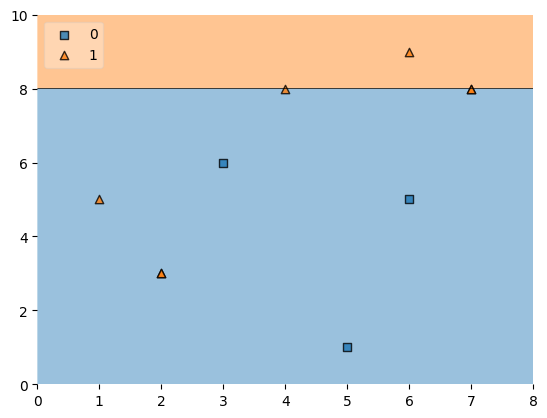

In [37]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [38]:
second_df['y_pred'] = dt2.predict(X)

In [39]:
second_df

,x1,x2,label,weights,y_pred
1,2,3,1,0.1,0
6,6,5,0,0.1,0
1,2,3,1,0.1,0
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
0,1,5,1,0.1,0
2,3,6,0,0.1,0
7,7,8,1,0.1,1
7,7,8,1,0.1,1


In [40]:
alpha2 = calc_model_wt(0.3)

In [41]:
alpha2

np.float64(0.42364893019360184)

In [42]:
def update_row_wt(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights']*np.exp(-alpha)
  else:
    return row['weights']*np.exp(alpha)


In [43]:
second_df['updated_weights'] = second_df.apply(update_row_wt,axis=1)

In [44]:
second_df

,x1,x2,label,weights,y_pred,updated_weights
1,2,3,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
1,2,3,1,0.1,0,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
0,1,5,1,0.1,0,0.152653
2,3,6,0,0.1,0,0.065508
7,7,8,1,0.1,1,0.065508
7,7,8,1,0.1,1,0.065508


In [45]:
second_df['normalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [46]:
second_df

,x1,x2,label,weights,y_pred,updated_weights,normalized_weights
1,2,3,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
1,2,3,1,0.1,0,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
0,1,5,1,0.1,0,0.152653,0.166559
2,3,6,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,1,0.065508,0.071475
7,7,8,1,0.1,1,0.065508,0.071475


In [47]:
second_df['normalized_weights'].sum()

np.float64(1.0)

In [49]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])

In [50]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

In [52]:
second_df[['x1','x2','label','weights','y_pred','normalized_weights','cumsum_lower','cumsum_upper']]


,x1,x2,label,weights,y_pred,normalized_weights,cumsum_lower,cumsum_upper
1,2,3,1,0.1,0,0.166559,0.000000,0.166559
6,6,5,0,0.1,0,0.071475,0.166559,0.238033
1,2,3,1,0.1,0,0.166559,0.238033,0.404592
3,4,8,1,0.1,1,0.071475,0.404592,0.476067
4,5,1,0,0.1,0,0.071475,0.476067,0.547542
5,6,9,1,0.1,1,0.071475,0.547542,0.619017
0,1,5,1,0.1,0,0.166559,0.619017,0.785575
2,3,6,0,0.1,0,0.071475,0.785575,0.857050
7,7,8,1,0.1,1,0.071475,0.857050,0.928525
7,7,8,1,0.1,1,0.071475,0.928525,1.000000


In [53]:
index_values = create_new_dataset(second_df)

In [54]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [55]:
third_df

,x1,x2,label,weights
2,3,6,0,0.1
4,5,1,0,0.1
0,1,5,1,0.1
6,6,5,0,0.1
1,2,3,1,0.1
6,6,5,0,0.1
1,2,3,1,0.1
1,2,3,1,0.1
4,5,1,0,0.1
6,6,5,0,0.1


In [58]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = third_df.iloc[:,0:2].values
y = third_df.iloc[:,2].values

dt3.fit(X,y)


DecisionTreeClassifier(max_depth=1)

<Axes: >

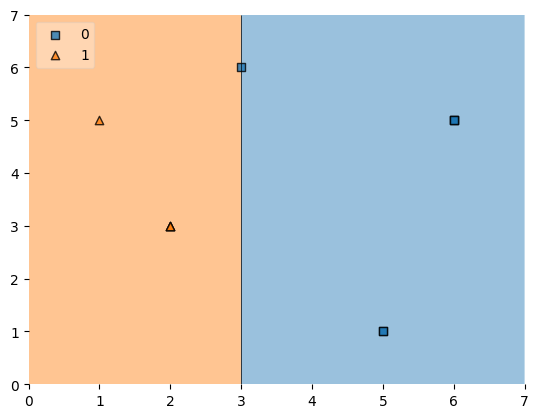

In [59]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [60]:
third_df['y_pred'] = dt3.predict(X)

In [61]:
third_df

,x1,x2,label,weights,y_pred
2,3,6,0,0.1,0
4,5,1,0,0.1,0
0,1,5,1,0.1,1
6,6,5,0,0.1,0
1,2,3,1,0.1,1
6,6,5,0,0.1,0
1,2,3,1,0.1,1
1,2,3,1,0.1,1
4,5,1,0,0.1,0
6,6,5,0,0.1,0


In [67]:
alpha3 = calc_model_wt(0)
alpha3

10.0

In [62]:
# prediction
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)


array([1])

In [63]:
dt2.predict(query)

array([0])

In [64]:
dt3.predict(query)

array([1])

In [68]:
alpha1*1 + alpha2*(0) + alpha3*(1)

np.float64(10.423648930193602)

In [69]:
np.sign(10.423648930193602)

np.float64(1.0)